# Heavy-chain V-gene × germline-AA × LC pairing bias

## Motivation

The companion notebook `rates_lc_within_family_entrenched_germline_aa_stratified.ipynb`
found that the kappa-vs-lambda selection-rate differences observed at entrenched sites
are explained by heavy-chain **V genes having different κ/λ pairing rates**, not by
LC-modulated selection. That reframes the interesting question: rather than asking
"does the LC change the selection pressure at site s?", we ask

> **Does the germline residue at site s predict whether the heavy chain pairs
> with κ or λ?**

If certain residues at certain sites are only compatible with one LC framework,
V genes carrying those residues should pair preferentially with that LC. This
notebook tests that hypothesis across the entire repertoire.

## Framing and caveats

- **Unit of analysis:** the clonal family `(sample_id, family)`. A family is one H–L
  pairing event followed by clonal expansion and hypermutation. Mutation-event counts
  pseudoreplicate across hypermutation and are wrong for pairing-bias questions.
- **Collinearity with V gene.** Germline AA at a site is deterministic given the V
  gene (up to allelic variation). Within a V family, different V genes carry different
  residues at a site — which means the test "within V family F, does germline AA at
  site s predict LC?" reduces to "within F, do V genes with different residues at s
  pair with LC differently?" This localizes V-gene pairing bias to specific sites/
  residues; it does not prove residue-level causation.
- **Donor clustering.** Even at the family level, families within one donor are not
  fully independent if that donor has a clonal expansion. All findings are re-verified
  under donor-deduplication (at most one family per `(sample_id, v_gene, LC)`).
- **Receptor-editing order.** A V gene may pair preferentially with λ because it
  tends to rearrange in cells whose κ locus was already non-productive. This
  observational analysis cannot distinguish that from structural compatibility.

## Inputs

Loads `checkpoints/families_lc_pairing.pkl` written by the companion notebook. This
file contains one row per clonal family with heavy-chain V gene, light-chain type,
and the germline amino acid at every heavy-chain site.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, binomtest
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multitest import multipletests

plt.rcParams['figure.dpi'] = 110

CHECKPOINT = 'checkpoints/families_lc_pairing.pkl'
assert os.path.isfile(CHECKPOINT), (
    f"Checkpoint {CHECKPOINT} not found. Run the Analysis C section of "
    f"rates_lc_within_family_entrenched_germline_aa_stratified.ipynb first."
)

families = pd.read_pickle(CHECKPOINT)
germ_cols = [c for c in families.columns if c.startswith('germ_')]
sites_all = [c.removeprefix('germ_') for c in germ_cols]

print(f"Loaded {len(families):,} families with LC annotation.")
print(f"  κ: {(families.light_chain_type == 'kappa').sum():,}")
print(f"  λ: {(families.light_chain_type == 'lambda').sum():,}")
baseline_kappa = (families.light_chain_type == 'kappa').mean()
print(f"  Baseline κ fraction: {baseline_kappa:.3f}")
print(f"  Sites with germline-AA data: {len(sites_all)}")
print(f"  V families present: {sorted(families.v_family.dropna().unique())}")


Loaded 50,768 families with LC annotation.
  κ: 31,401
  λ: 19,367
  Baseline κ fraction: 0.619
  Sites with germline-AA data: 102
  V families present: ['IGHV1', 'IGHV2', 'IGHV3', 'IGHV4', 'IGHV5', 'IGHV6', 'IGHV7']


## 1. Per-V-family baseline κ fraction

V families differ in their background κ/λ pairing rates just by virtue of which V
genes they contain. Compute the baseline per V family so per-site tests can be
interpreted against the right null.


In [2]:
per_vfamily = (
    families.groupby('v_family')
    .agg(
        n_families=('family', 'size'),
        n_kappa=('light_chain_type', lambda x: (x == 'kappa').sum()),
    )
    .reset_index()
)
per_vfamily['n_lambda'] = per_vfamily['n_families'] - per_vfamily['n_kappa']
per_vfamily['kappa_frac'] = per_vfamily['n_kappa'] / per_vfamily['n_families']
lo, hi = proportion_confint(per_vfamily['n_kappa'], per_vfamily['n_families'],
                             method='wilson')
per_vfamily['kappa_lo'] = lo
per_vfamily['kappa_hi'] = hi

per_vfamily = per_vfamily.sort_values('n_families', ascending=False).reset_index(drop=True)
print("Per-V-family κ fraction at the family level:")
print(per_vfamily.round(3).to_string(index=False))


Per-V-family κ fraction at the family level:
v_family  n_families  n_kappa  n_lambda  kappa_frac  kappa_lo  kappa_hi
   IGHV3       28418    18256     10162       0.642     0.637     0.648
   IGHV4       11418     6714      4704       0.588     0.579     0.597
   IGHV1        5900     3618      2282       0.613     0.601     0.626
   IGHV5        2245     1234      1011       0.550     0.529     0.570
   IGHV2        1564      855       709       0.547     0.522     0.571
   IGHV6         621      416       205       0.670     0.632     0.706
   IGHV7         602      308       294       0.512     0.472     0.551


## 2. Per-V-gene scan

For each heavy-chain V gene with at least `MIN_FAMILIES_VGENE` clonal families,
compute the κ fraction with Wilson CIs and a binomial test against the **V-family
baseline** (not the global one — we want to detect genes that deviate from their
own family's pairing rate, not just the family-level composition).


In [3]:
MIN_FAMILIES_VGENE = 20

per_vgene = (
    families.groupby(['v_gene', 'v_family'])
    .agg(
        n_families=('family', 'size'),
        n_kappa=('light_chain_type', lambda x: (x == 'kappa').sum()),
    )
    .reset_index()
)
per_vgene['n_lambda'] = per_vgene['n_families'] - per_vgene['n_kappa']
per_vgene['kappa_frac'] = per_vgene['n_kappa'] / per_vgene['n_families']

lo, hi = proportion_confint(per_vgene['n_kappa'], per_vgene['n_families'],
                             method='wilson')
per_vgene['kappa_lo'] = lo
per_vgene['kappa_hi'] = hi

# Attach V-family baseline and test against it
vf_baseline = per_vfamily.set_index('v_family')['kappa_frac'].to_dict()
per_vgene['vfamily_baseline'] = per_vgene['v_family'].map(vf_baseline)
per_vgene['delta_vs_vfamily'] = per_vgene['kappa_frac'] - per_vgene['vfamily_baseline']

def safe_binomtest(k, n, p):
    if n < MIN_FAMILIES_VGENE or not (0 < p < 1):
        return np.nan
    return binomtest(int(k), int(n), p=float(p)).pvalue

per_vgene['p_value'] = per_vgene.apply(
    lambda r: safe_binomtest(r['n_kappa'], r['n_families'], r['vfamily_baseline']),
    axis=1,
)
per_vgene['p_bh'] = np.nan
mask = per_vgene['p_value'].notna()
if mask.sum() > 0:
    _, p_bh, _, _ = multipletests(per_vgene.loc[mask, 'p_value'], method='fdr_bh')
    per_vgene.loc[mask, 'p_bh'] = p_bh

per_vgene = per_vgene.sort_values('p_value', na_position='last').reset_index(drop=True)

sig = per_vgene[(per_vgene['p_bh'] < 0.05)]
print(f"V genes tested (n_families >= {MIN_FAMILIES_VGENE}): {mask.sum()}")
print(f"V genes with BH<0.05 deviation from V-family baseline: {len(sig)}")
print()
if len(sig) > 0:
    print("BH-significant V genes, sorted by |Δκ vs V-family|:")
    sig_sorted = sig.reindex(
        sig['delta_vs_vfamily'].abs().sort_values(ascending=False).index
    )
    print(sig_sorted[['v_gene', 'v_family', 'n_families', 'kappa_frac',
                      'vfamily_baseline', 'delta_vs_vfamily',
                      'kappa_lo', 'kappa_hi', 'p_bh']]
          .round(3).to_string(index=False))


V genes tested (n_families >= 20): 81
V genes with BH<0.05 deviation from V-family baseline: 33

BH-significant V genes, sorted by |Δκ vs V-family|:
                 v_gene v_family  n_families  kappa_frac  vfamily_baseline  delta_vs_vfamily  kappa_lo  kappa_hi  p_bh
            IGHV3-72*01    IGHV3         527       0.861             0.642             0.219     0.829     0.888 0.000
            IGHV3-33*01    IGHV3         586       0.490             0.642            -0.153     0.449     0.530 0.000
            IGHV3-49*05    IGHV3         115       0.774             0.642             0.132     0.689     0.841 0.011
             IGHV1-2*04    IGHV1         107       0.486             0.613            -0.127     0.393     0.580 0.027
            IGHV3-73*01    IGHV3         114       0.518             0.642            -0.125     0.427     0.607 0.018
IGHV3-23*01+G147A.C148G    IGHV3         177       0.763             0.642             0.120     0.695     0.819 0.003
            IGHV3-

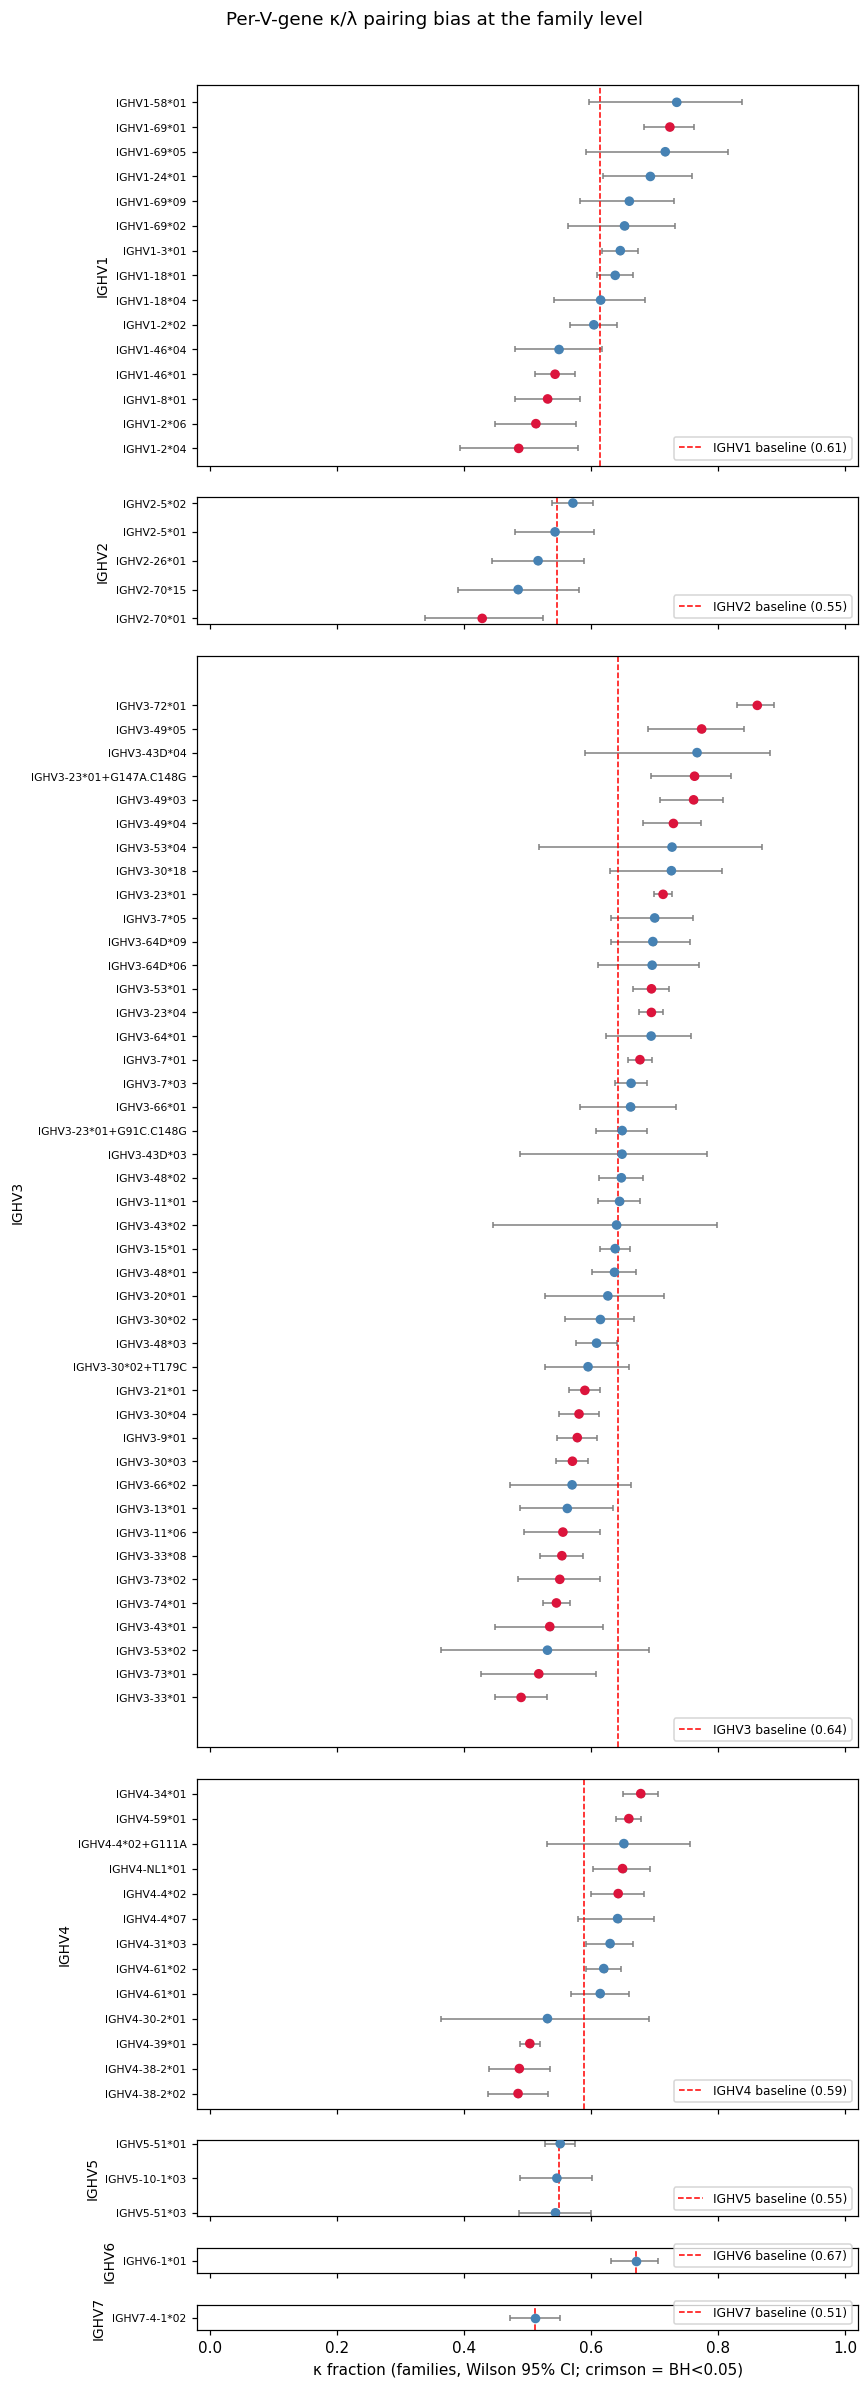

In [4]:
# Forest plot of per-V-gene κ fractions, one panel per V family. Each dot is
# a V gene with its Wilson 95% CI. The red line is the V-family baseline.
testable = per_vgene[per_vgene['n_families'] >= MIN_FAMILIES_VGENE].copy()
v_families_present = sorted(testable['v_family'].unique())

fig, axes = plt.subplots(
    len(v_families_present), 1,
    figsize=(8, 1.2 + 0.25 * len(testable)),
    sharex=True,
    gridspec_kw={'height_ratios':
                  [max(1, (testable.v_family == vf).sum())
                   for vf in v_families_present]},
)
if len(v_families_present) == 1:
    axes = [axes]

for ax, vf in zip(axes, v_families_present):
    sub = testable[testable.v_family == vf].sort_values('kappa_frac')
    y = np.arange(len(sub))
    xerr = np.array([sub['kappa_frac'] - sub['kappa_lo'],
                     sub['kappa_hi'] - sub['kappa_frac']])
    colors = ['crimson' if p < 0.05 else 'steelblue' for p in sub['p_bh'].fillna(1)]
    ax.errorbar(sub['kappa_frac'], y, xerr=xerr, fmt='o', ms=4, lw=1,
                ecolor='grey', capsize=2,
                mfc='none', mec='grey')
    ax.scatter(sub['kappa_frac'], y, c=colors, s=28, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(sub['v_gene'], fontsize=7)
    ax.axvline(vf_baseline[vf], color='red', linestyle='--', linewidth=1,
               label=f'{vf} baseline ({vf_baseline[vf]:.2f})')
    ax.set_xlim(-0.02, 1.02)
    ax.legend(loc='lower right', fontsize=8)
    ax.set_ylabel(vf, fontsize=9)

axes[-1].set_xlabel('κ fraction (families, Wilson 95% CI; crimson = BH<0.05)')
fig.suptitle('Per-V-gene κ/λ pairing bias at the family level', y=1.01)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/vgene_lc_pairing_forest.pdf', bbox_inches='tight')
plt.show()


## 3. Per-(V family, site) scan

For each V family, loop over every site that has germline-AA variation, build the
`germline AA × LC` contingency table, and run a chi-square test. Rank sites by
**specificity** (max − min κ fraction across germline residues within the V family)
paired with a **permutation p-value**: shuffle LC labels across families within the
V family and recompute the specificity score. The permutation null handles small
counts correctly and doesn't rely on chi-square asymptotics.


In [5]:
V_FAMILIES_SCAN = sorted([
    vf for vf in families.v_family.dropna().unique()
    if (families.v_family == vf).sum() >= 100
])
print(f"Scanning V families with >=100 families: {V_FAMILIES_SCAN}")

MIN_FAM_PER_AA = 10        # drop germline AAs with < this many families at the site
MIN_AAS_AT_SITE = 2        # need at least 2 germline AAs to compare
N_PERM = 2000

rng = np.random.default_rng(42)

def scan_site(fams_sub, site):
    col = f'germ_{site}'
    if col not in fams_sub.columns:
        return None
    sub = fams_sub[[col, 'light_chain_type']].dropna()
    if len(sub) == 0:
        return None

    ctab = pd.crosstab(sub[col], sub['light_chain_type'])
    for lc in ('kappa', 'lambda'):
        if lc not in ctab.columns:
            ctab[lc] = 0
    ctab = ctab[['kappa', 'lambda']]
    ctab = ctab[ctab.sum(axis=1) >= MIN_FAM_PER_AA]
    if ctab.shape[0] < MIN_AAS_AT_SITE:
        return None

    kappa_counts = ctab['kappa'].values.astype(float)
    lambda_counts = ctab['lambda'].values.astype(float)
    totals = kappa_counts + lambda_counts
    k_frac = kappa_counts / totals
    obs_spec = k_frac.max() - k_frac.min()

    try:
        chi2, p_chi, dof, _ = chi2_contingency(ctab.values)
    except ValueError:
        chi2, p_chi, dof = np.nan, np.nan, 0

    # --- Permutation null on specificity ---
    # Build an (n_families,) AA index and an (n_families,) κ indicator vector,
    # then shuffle the indicator and recompute per-AA κ fractions.
    aa_index = np.repeat(np.arange(ctab.shape[0]),
                          (kappa_counts + lambda_counts).astype(int))
    is_kappa = np.concatenate([
        np.concatenate([np.ones(int(k)), np.zeros(int(l))])
        for k, l in zip(kappa_counts, lambda_counts)
    ])
    n = len(is_kappa)

    perm_specs = np.empty(N_PERM)
    for i in range(N_PERM):
        shuffled = is_kappa[rng.permutation(n)]
        # Per-AA κ fraction under the permutation
        k_perm = np.bincount(aa_index, weights=shuffled,
                              minlength=ctab.shape[0])
        frac_perm = k_perm / totals
        perm_specs[i] = frac_perm.max() - frac_perm.min()

    p_perm = float(((perm_specs >= obs_spec).sum() + 1) / (N_PERM + 1))

    return {
        'v_family': fams_sub.name if hasattr(fams_sub, 'name') else None,
        'site': site,
        'n_aas': int(ctab.shape[0]),
        'n_families': int(totals.sum()),
        'chi2': float(chi2),
        'p_chi2': float(p_chi),
        'specificity': float(obs_spec),
        'p_perm': p_perm,
        'ctab': ctab,
    }

scan_rows = []
for vf in V_FAMILIES_SCAN:
    vf_fams = families[families.v_family == vf]
    for site in sites_all:
        r = scan_site(vf_fams, site)
        if r is not None:
            r['v_family'] = vf
            scan_rows.append(r)

scan_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k != 'ctab'} for r in scan_rows]
)
if len(scan_df) > 0:
    _, p_bh_chi, _, _ = multipletests(scan_df['p_chi2'], method='fdr_bh')
    _, p_bh_perm, _, _ = multipletests(scan_df['p_perm'], method='fdr_bh')
    scan_df['p_bh_chi2'] = p_bh_chi
    scan_df['p_bh_perm'] = p_bh_perm
    scan_df = scan_df.sort_values('p_perm').reset_index(drop=True)

print(f"Total (V family, site) cells scanned: {len(scan_df)}")
print(f"BH<0.05 by chi-square:   {(scan_df['p_bh_chi2'] < 0.05).sum()}")
print(f"BH<0.05 by permutation:  {(scan_df['p_bh_perm'] < 0.05).sum()}")


Scanning V families with >=100 families: ['IGHV1', 'IGHV2', 'IGHV3', 'IGHV4', 'IGHV5', 'IGHV6', 'IGHV7']


Total (V family, site) cells scanned: 151
BH<0.05 by chi-square:   97
BH<0.05 by permutation:  82


In [6]:
# Top 25 by permutation p-value, across all V families
print("Top 25 (V family, site) cells by permutation p-value:")
print(
    scan_df.head(25)
    [['v_family', 'site', 'n_aas', 'n_families', 'specificity',
      'chi2', 'p_chi2', 'p_bh_chi2', 'p_perm', 'p_bh_perm']]
    .round(4).to_string(index=False)
)


Top 25 (V family, site) cells by permutation p-value:
v_family site  n_aas  n_families  specificity     chi2  p_chi2  p_bh_chi2  p_perm  p_bh_perm
   IGHV1   30      2        4627       0.0937  17.8578  0.0000     0.0001  0.0005     0.0016
   IGHV1   50      4        5138       0.1692  46.2644  0.0000     0.0000  0.0005     0.0016
   IGHV1   54      6        4611       0.2010  67.4435  0.0000     0.0000  0.0005     0.0016
   IGHV1   69      2        5191       0.0828  32.0679  0.0000     0.0000  0.0005     0.0016
   IGHV1   75      3        5562       0.0851  18.4743  0.0001     0.0002  0.0005     0.0016
   IGHV1   78      2        5046       0.0851  23.9611  0.0000     0.0000  0.0005     0.0016
   IGHV3   73      2       25291       0.0521  32.1047  0.0000     0.0000  0.0005     0.0016
   IGHV4   12      2       11112       0.0997  38.5679  0.0000     0.0000  0.0005     0.0016
   IGHV4    2      2       10845       0.1257 152.0895  0.0000     0.0000  0.0005     0.0016
   IGHV4   23   

In [7]:
# Per-AA breakdowns for the top 8 permutation hits
top_perm = scan_df.head(8)
for _, row in top_perm.iterrows():
    r_full = next(r for r in scan_rows
                  if r['v_family'] == row['v_family'] and r['site'] == row['site'])
    ctab = r_full['ctab'].copy()
    ctab['total'] = ctab.sum(axis=1)
    ctab['kappa_frac'] = ctab['kappa'] / ctab['total']
    ctab = ctab.sort_values('kappa_frac')
    print(f"── {row['v_family']} site {row['site']}  "
          f"(Δκ={row['specificity']:.3f}, perm p={row['p_perm']:.4f}, "
          f"BH={row['p_bh_perm']:.4f}, n={int(row['n_families'])}) ──")
    print(ctab.round(3).to_string())
    print()


── IGHV1 site 30  (Δκ=0.094, perm p=0.0005, BH=0.0016, n=4627) ──
light_chain_type  kappa  lambda  total  kappa_frac
germ_30                                           
T                  2416    1646   4062       0.595
S                   389     176    565       0.688

── IGHV1 site 50  (Δκ=0.169, perm p=0.0005, BH=0.0016, n=5138) ──
light_chain_type  kappa  lambda  total  kappa_frac
germ_50                                           
I                   456     354    810       0.563
R                   247     186    433       0.570
W                  2046    1274   3320       0.616
G                   421     154    575       0.732

── IGHV1 site 54  (Δκ=0.201, perm p=0.0005, BH=0.0016, n=4611) ──
light_chain_type  kappa  lambda  total  kappa_frac
germ_54                                           
G                   457     396    853       0.536
S                   642     476   1118       0.574
N                  1222     672   1894       0.645
L                   122      67    

## 4. Donor sanity check on top hits

For each of the top permutation hits, rerun the scan on the donor-deduplicated
frame (at most one family per `(sample_id, v_gene, light_chain_type)`) and see
whether the specificity and p-value survive. A hit that evaporates under
deduplication is driven by one donor's clonal expansion.


In [8]:
families_dd = families.drop_duplicates(
    subset=['sample_id', 'v_gene', 'light_chain_type']
)
print(f"Original:   {len(families):,} families")
print(f"Donor-dd:   {len(families_dd):,} families")
print()

TOP_K = 15
top_hits = scan_df.head(TOP_K)

dd_rows = []
for _, row in top_hits.iterrows():
    vf_fams = families_dd[families_dd.v_family == row['v_family']]
    # Relax the per-AA minimum because donor-dd shrinks counts
    r = scan_site(vf_fams, row['site'])
    if r is None:
        # Try again with a looser min
        saved_min = None
        # scan_site uses module-level constants; do a manual version
        col = f"germ_{row['site']}"
        sub = vf_fams[[col, 'light_chain_type']].dropna()
        ctab = pd.crosstab(sub[col], sub['light_chain_type'])
        for lc in ('kappa', 'lambda'):
            if lc not in ctab.columns:
                ctab[lc] = 0
        ctab = ctab[['kappa', 'lambda']]
        ctab = ctab[ctab.sum(axis=1) >= 3]
        if ctab.shape[0] >= 2:
            k = ctab['kappa'].values.astype(float)
            l = ctab['lambda'].values.astype(float)
            t = k + l
            spec = (k/t).max() - (k/t).min()
            try:
                chi2, p_chi, _, _ = chi2_contingency(ctab.values)
            except ValueError:
                chi2, p_chi = np.nan, np.nan
            dd_rows.append({
                'v_family': row['v_family'], 'site': row['site'],
                'specificity_dd': spec, 'p_chi2_dd': p_chi,
                'n_families_dd': int(t.sum()),
            })
        else:
            dd_rows.append({
                'v_family': row['v_family'], 'site': row['site'],
                'specificity_dd': np.nan, 'p_chi2_dd': np.nan,
                'n_families_dd': int((sub.shape[0]) if len(sub) else 0),
            })
    else:
        dd_rows.append({
            'v_family': row['v_family'], 'site': row['site'],
            'specificity_dd': r['specificity'], 'p_chi2_dd': r['p_chi2'],
            'n_families_dd': r['n_families'],
        })

dd_df = pd.DataFrame(dd_rows)
compare = top_hits[['v_family', 'site', 'n_families', 'specificity',
                     'p_chi2', 'p_perm']].merge(
    dd_df, on=['v_family', 'site'], how='left'
)
print("Top permutation hits before vs after donor deduplication:")
print(compare.round(4).to_string(index=False))


Original:   50,768 families
Donor-dd:   413 families



Top permutation hits before vs after donor deduplication:
v_family site  n_families  specificity  p_chi2  p_perm  specificity_dd  p_chi2_dd  n_families_dd
   IGHV1   30        4627       0.0937  0.0000  0.0005          0.0627     0.9029             71
   IGHV1   50        5138       0.1692  0.0000  0.0005          0.0571     0.9289             69
   IGHV1   54        4611       0.2010  0.0000  0.0005          0.0000     1.0000             42
   IGHV1   69        5191       0.0828  0.0000  0.0005          0.0500     0.8407             76
   IGHV1   75        5562       0.0851  0.0001  0.0005          0.0010     1.0000             69
   IGHV1   78        5046       0.0851  0.0000  0.0005          0.0224     1.0000             75
   IGHV3   73       25291       0.0521  0.0000  0.0005          0.0099     1.0000            186
   IGHV4   12       11112       0.0997  0.0000  0.0005          0.0273     1.0000             63
   IGHV4    2       10845       0.1257  0.0000  0.0005          0.100

## 5. Along-gene plot: specificity per site

Scatter the specificity score per site for each V family. Sites above the dashed
line (95th percentile of the permutation null) are candidates; sites marked in red
are BH-significant by permutation.


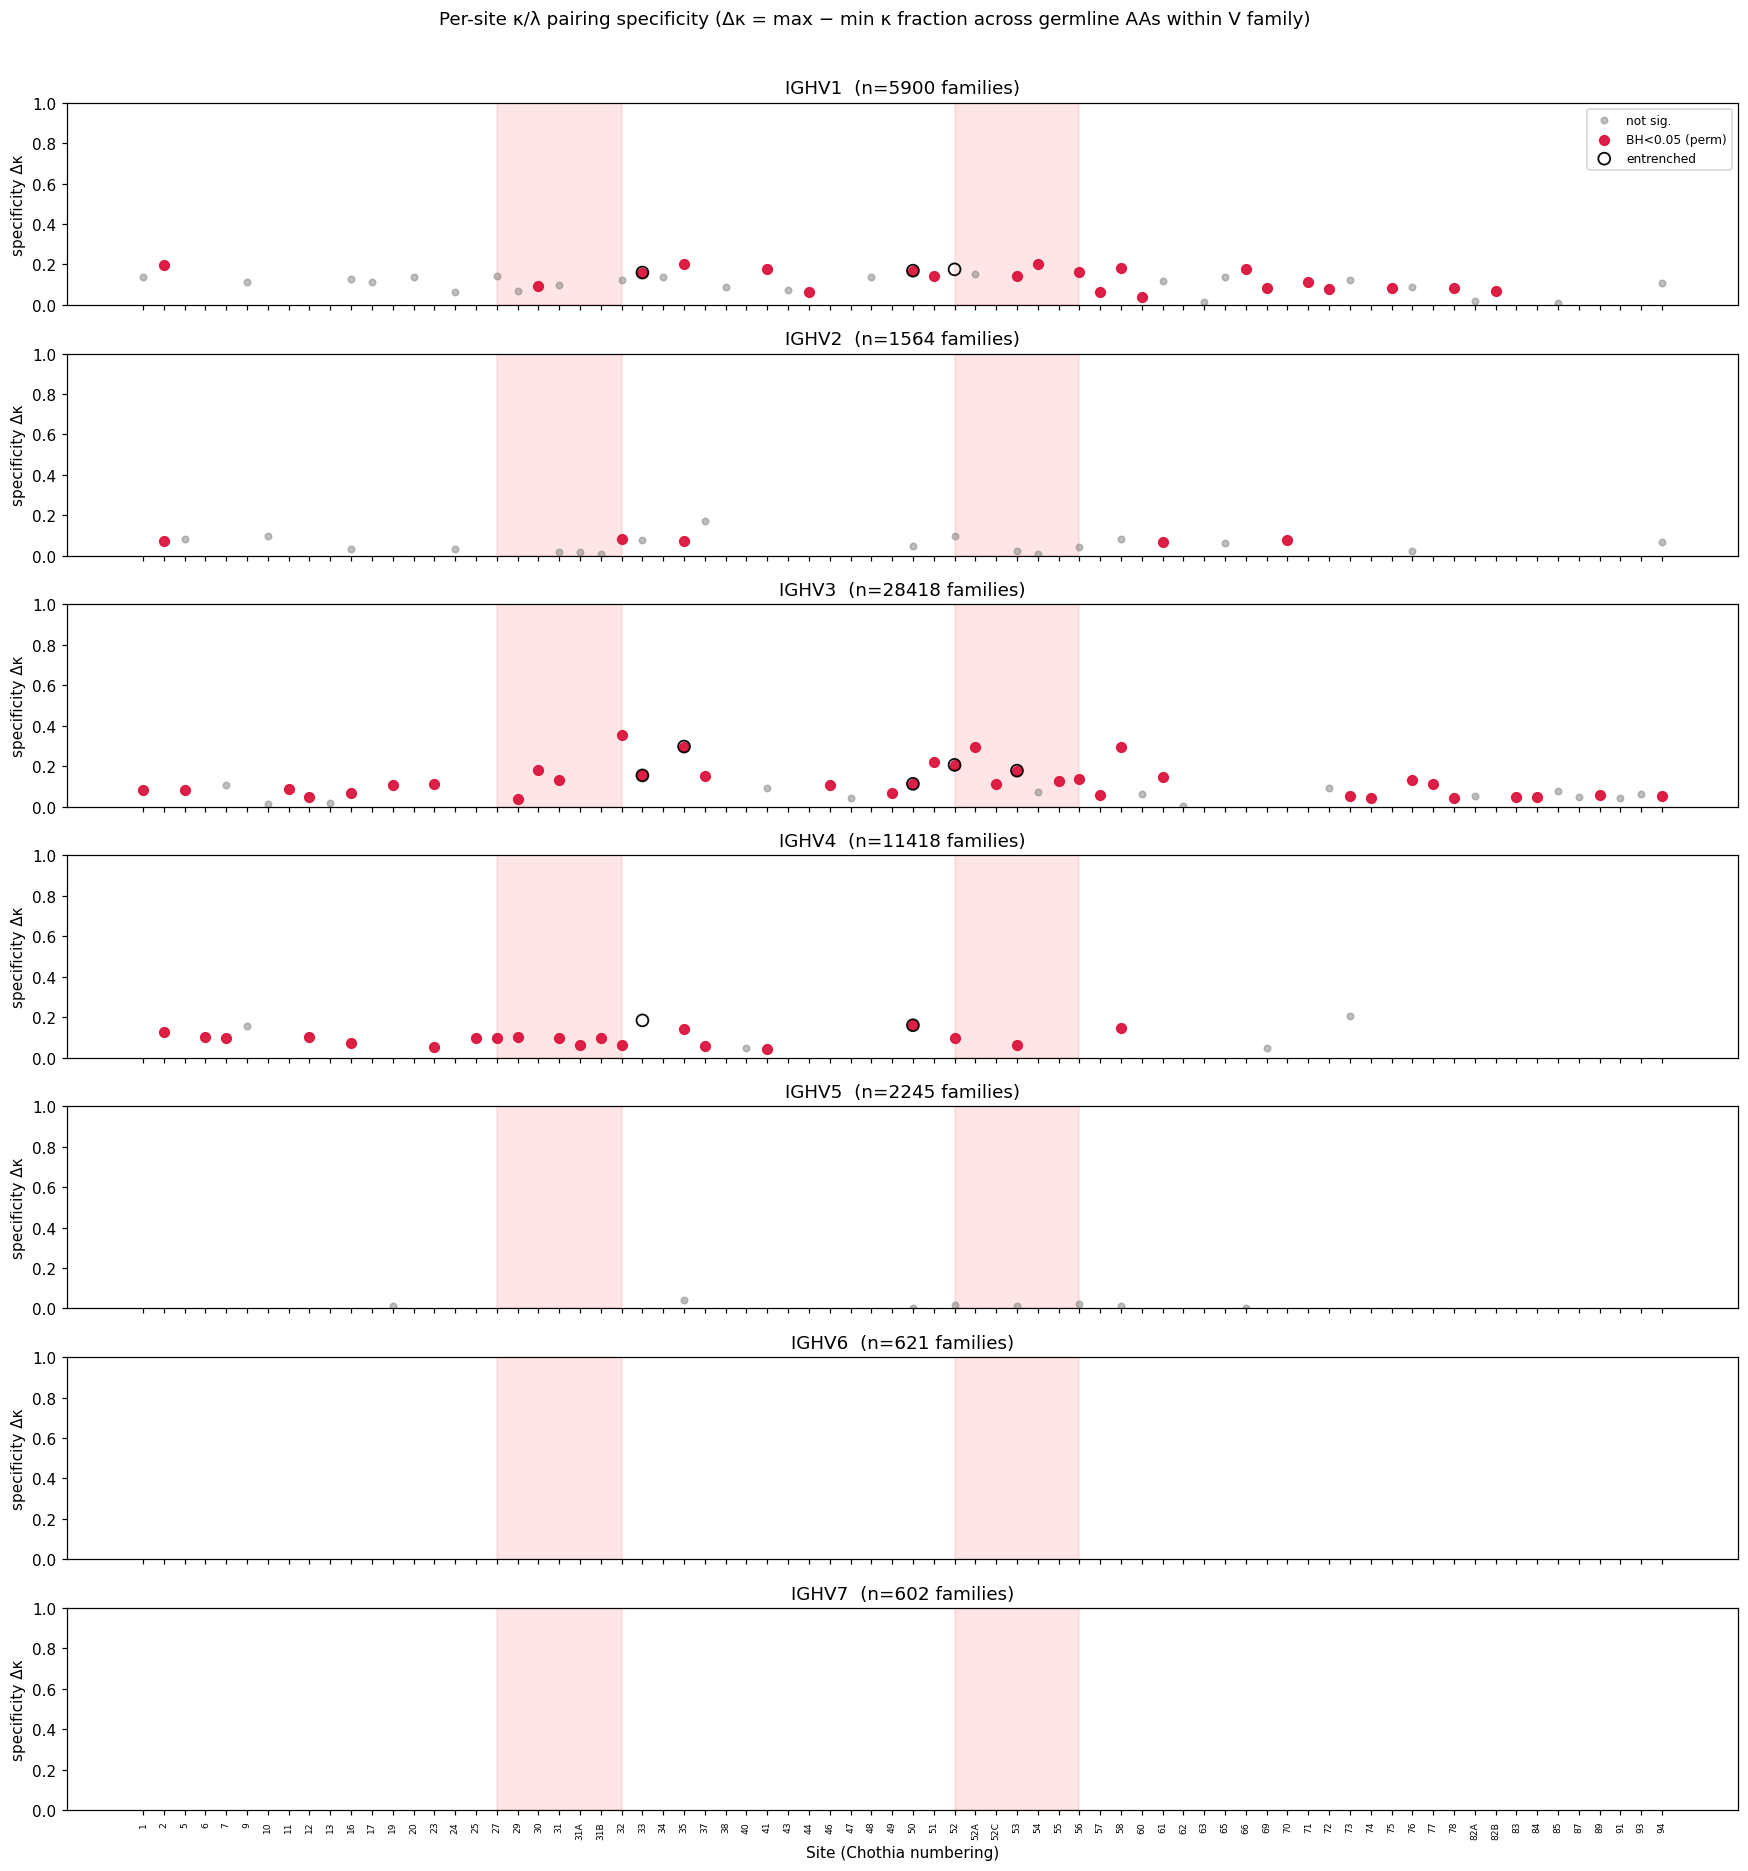

In [9]:
from utils import sort_antibody_sites, add_cdr_shading

sites_sorted = sort_antibody_sites(scan_df['site'].unique())
site_pos = {s: i for i, s in enumerate(sites_sorted)}

# Entrenched sites for overlay (from the companion analysis)
try:
    from utils import load_entrenched_sites
    _, _, _, _, within_dfs, _ = load_entrenched_sites('chothia')
    within_dfs['site'] = within_dfs['site'].astype(str)
    entrenched_pairs = set(zip(within_dfs['site'], within_dfs['v_family']))
except Exception:
    entrenched_pairs = set()

fig, axes = plt.subplots(len(V_FAMILIES_SCAN), 1,
                          figsize=(16, 2.4 * len(V_FAMILIES_SCAN)),
                          sharex=True)
if len(V_FAMILIES_SCAN) == 1:
    axes = [axes]

for ax, vf in zip(axes, V_FAMILIES_SCAN):
    sub = scan_df[scan_df.v_family == vf]
    add_cdr_shading(ax, sites_sorted, numbering_scheme='chothia')
    xs = [site_pos[s] for s in sub['site']]
    ys = sub['specificity'].values
    is_sig = (sub['p_bh_perm'].fillna(1.0) < 0.05).to_numpy(dtype=bool)
    is_entrenched = np.array(
        [(s, vf) in entrenched_pairs for s in sub['site']], dtype=bool
    )
    xs_arr = np.asarray(xs)
    # Non-significant
    ax.scatter(xs_arr[~is_sig & ~is_entrenched],
               ys[~is_sig & ~is_entrenched],
               s=18, alpha=0.5, color='grey', label='not sig.')
    # BH-significant
    ax.scatter(xs_arr[is_sig],
               ys[is_sig],
               s=40, alpha=0.95, color='crimson', label='BH<0.05 (perm)')
    # Entrenched sites
    ax.scatter(xs_arr[is_entrenched],
               ys[is_entrenched],
               s=60, alpha=0.95, facecolors='none', edgecolors='black',
               linewidth=1.2, label='entrenched')
    ax.set_ylabel('specificity Δκ')
    ax.set_title(f'{vf}  (n={int((families.v_family == vf).sum())} families)')
    ax.set_ylim(0, max(1.0, ys.max() * 1.05) if len(ys) else 1.0)
    if ax is axes[0]:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xticks(range(len(sites_sorted)))
axes[-1].set_xticklabels(sites_sorted, rotation=90, fontsize=6)
axes[-1].set_xlabel('Site (Chothia numbering)')

fig.suptitle('Per-site κ/λ pairing specificity (Δκ = max − min κ fraction across '
             'germline AAs within V family)', y=1.01)
plt.tight_layout()
plt.savefig('figures/vgene_lc_pairing_along_gene.pdf', bbox_inches='tight')
plt.show()


## 6. Intersection with entrenched sites

Do the entrenched (site, V family) pairs from the entrenched-sites analysis show up
among the pairing-bias hits? Two different biological stories that might or might
not coincide.


In [10]:
if entrenched_pairs:
    scan_df['is_entrenched'] = [
        (s, vf) in entrenched_pairs
        for s, vf in zip(scan_df['site'], scan_df['v_family'])
    ]
    ent_scan = scan_df[scan_df.is_entrenched].sort_values('p_perm')
    print(f"Entrenched (site, V family) pairs in the scan: {len(ent_scan)}")
    print()
    print(ent_scan[['v_family', 'site', 'n_aas', 'n_families',
                    'specificity', 'p_perm', 'p_bh_perm']]
          .round(4).to_string(index=False))
    print()
    n_ent_sig = (ent_scan['p_bh_perm'] < 0.05).sum()
    print(f"Entrenched sites with BH<0.05 pairing-bias signal: {n_ent_sig}")
else:
    print("Entrenched site annotations unavailable in this environment.")


Entrenched (site, V family) pairs in the scan: 10

v_family site  n_aas  n_families  specificity  p_perm  p_bh_perm
   IGHV1   50      4        5138       0.1692  0.0005     0.0016
   IGHV3   53      5       22564       0.1780  0.0005     0.0016
   IGHV3   35      4       20797       0.2972  0.0005     0.0016
   IGHV3   52      7       21746       0.2066  0.0005     0.0016
   IGHV4   50      4        9190       0.1597  0.0005     0.0016
   IGHV3   50      9       19781       0.1129  0.0095     0.0208
   IGHV3   33      8       23170       0.1545  0.0100     0.0216
   IGHV1   33      6        4595       0.1599  0.0230     0.0434
   IGHV1   52      5        4988       0.1756  0.0365     0.0619
   IGHV4   33      3        9698       0.1837  0.0570     0.0915

Entrenched sites with BH<0.05 pairing-bias signal: 8


## Summary

What we set out to ask: **do specific germline residues at specific heavy-chain
sites predict κ/λ light-chain pairing?**

- **Per-V-gene baseline (Section 2).** A V gene that deviates from its V-family
  baseline is the raw unit of pairing bias. If nothing is BH-significant here, there
  is no signal to localize and the rest of the notebook is moot.
- **Per-(V family, site) scan (Section 3).** Within each V family, we test whether
  germline AA at each site predicts LC pairing, quantifying the spread across
  residues with the specificity score and getting a small-count-safe p-value from
  permutation.
- **Donor sanity check (Section 4).** Distinguishes cross-donor biology from
  single-donor clonal expansions.
- **Entrenched-site overlap (Section 6).** Tells us whether the pairing-bias story
  is independent of, or connected to, the entrenched-site selection story.

If the scan flags a set of structurally plausible sites (VH-VL interface residues
near Kabat 35/37/39/45/47/89/91) with large specificity scores that survive donor
deduplication, that's a positive finding worth writing up. If it doesn't, the
entrenched-site analysis's null result is simply a null result, and the V-gene
composition confound is a methodological note rather than a new biological claim.
